# Eating-Gesture Classification from AirPod IMU Data

Classifies food types (**Apfel**, **Kaugummi**, **Skyr**, **Still**) from AirPod
motion data recorded via the Sensor Logger iOS app at ~50 Hz.

**Pipeline:**
1. Load raw ZIP sessions from `data/raw/`
2. Preprocess (trim, compute linear acceleration & magnitude)
3. Visualise magnitude signal per class
4. Extract 36 hand-crafted features per session
5. Classify with Random Forest + Leave-One-Out CV
6. Evaluate with a confusion matrix

In [94]:
import zipfile
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.signal import welch
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import accuracy_score, confusion_matrix

sns.set_theme(style="whitegrid", palette="muted")
%matplotlib inline

## 1. Load Data

Scan `data/raw/` for ZIP files, count sessions per class, then load `N_SESSIONS`
per class. Adjust `N_SESSIONS` below if you want fewer sessions.

In [95]:
DATA_DIR = Path("../data/raw")
CLASSES   = ["Apfel", "Kaugummi", "Skyr", "Still"]
FS        = 50.0  # nominal sampling rate (Hz)

sessions: dict[str, list[Path]] = {cls: [] for cls in CLASSES}
for zf in sorted(DATA_DIR.glob("*.zip")):
    for cls in CLASSES:
        if zf.name.startswith(cls + "_"):
            sessions[cls].append(zf)
            break

print("Sessions available per class:")
for cls in CLASSES:
    print(f"  {cls:12s}: {len(sessions[cls])}")

min_available = min(len(v) for v in sessions.values())
print(f"\nMinimum across all classes: {min_available}")

Sessions available per class:
  Apfel       : 6
  Kaugummi    : 6
  Skyr        : 7
  Still       : 9

Minimum across all classes: 6


In [96]:
# ── How many sessions per class to use ───────────────────────────────────
N_SESSIONS = min_available  # lower this number to use fewer sessions
# ─────────────────────────────────────────────────────────────────────────

n = min(max(1, N_SESSIONS), min_available)
print(f"Loading {n} sessions per class ({n * len(CLASSES)} total).")

_SKIP = {"Metadata.csv", "Annotation.csv"}
loaded: dict[str, list[pd.DataFrame]] = {}
for cls in CLASSES:
    loaded[cls] = []
    for zf in sessions[cls][:n]:
        with zipfile.ZipFile(zf) as z:
            csv_name = next(
                fname for fname in z.namelist()
                if fname.endswith(".csv") and fname not in _SKIP
            )
            with z.open(csv_name) as f:
                loaded[cls].append(pd.read_csv(f))
    print(f"  {cls:12s}: {len(loaded[cls])} session(s) loaded")

first_df = next(iter(loaded.values()))[0]
print(f"\nShape of first session: {first_df.shape}")
print(f"Columns: {list(first_df.columns)}")

Loading 6 sessions per class (24 total).
  Apfel       : 6 session(s) loaded
  Kaugummi    : 6 session(s) loaded
  Skyr        : 6 session(s) loaded
  Still       : 6 session(s) loaded

Shape of first session: (3042, 19)
Columns: ['time', 'seconds_elapsed', 'roll', 'rotationRateZ', 'quaternionY', 'rotationRateY', 'quaternionZ', 'quaternionW', 'yaw', 'devicelocation', 'accelerationZ', 'pitch', 'gravityX', 'gravityZ', 'quaternionX', 'rotationRateX', 'accelerationX', 'gravityY', 'accelerationY']


**What just happened?**  
The script scanned `data/raw/` and grouped all ZIP files by class name. Each ZIP is one recording session (~60 s of AirPod motion data).

We always load exactly `N_SESSIONS` per class so every class is represented equally — a **balanced dataset**. This matters because an unbalanced classifier could achieve high accuracy simply by always predicting the majority class, which tells us nothing useful.

> **Adding more data:** drop new ZIP files (e.g. `Apfel_7.zip`) into `data/raw/` and re-run the notebook from here. `min_available` updates automatically, so no other changes are needed.

## 2. Preprocessing

For each session:
- **Trim** first and last 5 s (removes setup/teardown artefacts)
- **Linear acceleration**: Sensor Logger already outputs  as
  user acceleration with gravity removed (in g). The  columns are
  in m/s² — a different unit — so we use the acceleration columns directly.
- **Magnitude** = 

In [97]:
TRIM_SECS = 5

def preprocess(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    t = df["seconds_elapsed"]
    df = df[
        (t >= t.iloc[0] + TRIM_SECS) & (t <= t.iloc[-1] - TRIM_SECS)
    ].reset_index(drop=True)
    # accelerationX/Y/Z is already user acceleration (gravity removed by sensor, in g).
    # gravityX/Y/Z is in m/s2 — do NOT subtract directly (unit mismatch).
    df["lin_x"]     = df["accelerationX"]
    df["lin_y"]     = df["accelerationY"]
    df["lin_z"]     = df["accelerationZ"]
    df["magnitude"] = np.sqrt(df["lin_x"]**2 + df["lin_y"]**2 + df["lin_z"]**2)
    return df

preprocessed: dict[str, list[pd.DataFrame]] = {
    cls: [preprocess(df) for df in dfs]
    for cls, dfs in loaded.items()
}

print("Preprocessing done.")
for cls in CLASSES:
    ex  = preprocessed[cls][0]
    dur = ex["seconds_elapsed"].iloc[-1] - ex["seconds_elapsed"].iloc[0]
    print(f"  {cls:12s} — {len(ex):5d} samples,  {dur:.1f} s  |  magnitude mean={ex["magnitude"].mean():.4f} g")

Preprocessing done.
  Apfel        —  2540 samples,  50.8 s  |  magnitude mean=0.0240 g
  Kaugummi     —  2539 samples,  50.8 s  |  magnitude mean=0.0144 g
  Skyr         —  2557 samples,  51.1 s  |  magnitude mean=0.0146 g
  Still        —  1047 samples,  20.9 s  |  magnitude mean=0.0057 g


**Trimming** removes the first and last 5 seconds of each session.  
Those seconds contain artefacts: picking up the AirPods, starting/stopping the recording, adjusting position. They are not representative of the eating gesture.

**Why no gravity subtraction?**  
The Sensor Logger app uses Apple's sensor fusion (`CMHeadphoneMotionManager`) which already delivers *user acceleration* — the device has already removed gravity internally. So `accelerationX/Y/Z` is purely the motion component, in **g** (1 g ≈ 9.81 m/s²). The `gravityX/Y/Z` columns exist but are expressed in **m/s²**, a different unit. Subtracting them would mix incompatible units and produce physically meaningless values (we found this out the hard way: it makes the magnitude ≈ 9.81 for every class, giving flat lines and ~70 % accuracy).

**Magnitude** = √(x² + y² + z²) collapses the three acceleration axes into one scalar that captures *how much* the head/jaw is moving, regardless of direction. This is the primary signal we work with throughout the analysis.

## 3. Visualisation

Magnitude signal of one representative session per class, stacked for comparison.

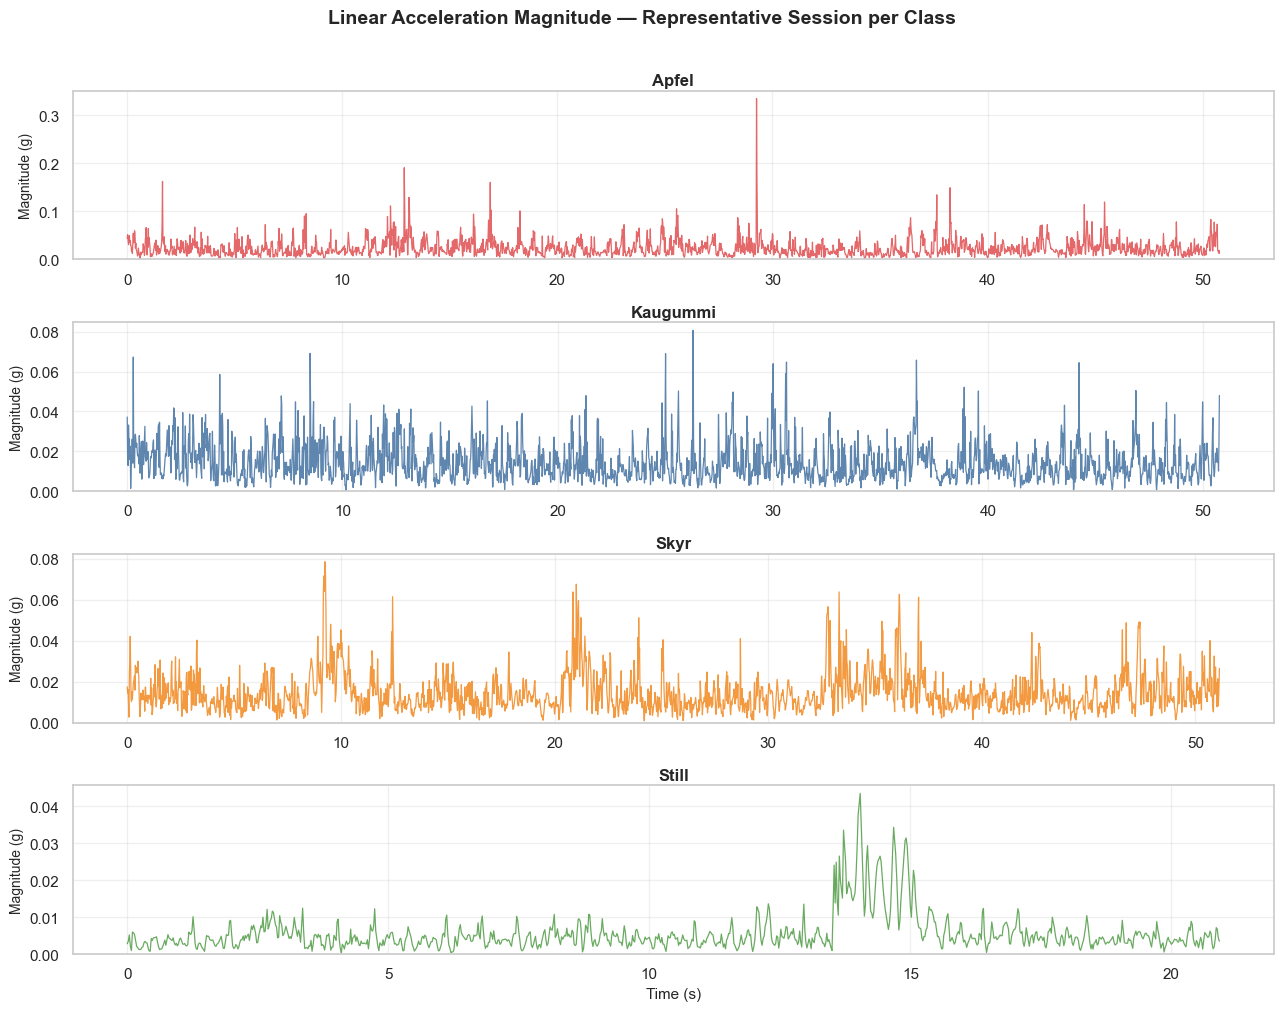

In [98]:
COLORS = {"Apfel": "#e15759", "Kaugummi": "#4e79a7",
          "Skyr":  "#f28e2b", "Still":    "#59a14f"}

fig, axes = plt.subplots(4, 1, figsize=(13, 10), sharex=False)

for ax, cls in zip(axes, CLASSES):
    df = preprocessed[cls][0]
    t  = df["seconds_elapsed"] - df["seconds_elapsed"].iloc[0]
    ax.plot(t, df["magnitude"], color=COLORS[cls], linewidth=0.9, alpha=0.9)
    ax.set_title(cls, fontsize=12, fontweight="bold", pad=4)
    ax.set_ylabel("Magnitude (g)", fontsize=10)
    ax.set_ylim(bottom=0)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel("Time (s)", fontsize=11)
fig.suptitle(
    "Linear Acceleration Magnitude — Representative Session per Class",
    fontsize=14, fontweight="bold", y=1.01,
)
plt.tight_layout()
plt.show()

**How to read the plots:**

| Class | What you see | Physical reason |
|---|---|---|
| **Apfel** (apple) | Large, sharp, rhythmic spikes | Each spike = one bite / crunch |
| **Kaugummi** (gum) | Smaller, more continuous oscillations | Sustained repetitive jaw motion |
| **Skyr** (yoghurt) | Mostly quiet, occasional bursts | Light jaw motion + occasional head movement |
| **Still** | Near-zero baseline, rare peaks | Sitting still; peaks = accidental head movement |

These visual differences justify the feature engineering in the next step: amplitude statistics, periodicity, and frequency content will all differ between classes.

## 4. Feature Extraction

36 features per session:

| Group | Features |
|---|---|
| **Time domain** | mean/std/max of lin\_x, lin\_y, lin\_z, magnitude; stillness\_ratio; movement\_events |
| **Gyroscope** | mean/std/max of rotationRateX/Y/Z |
| **Euler angles** | mean/std/range of pitch, roll, yaw |
| **Frequency domain** | dominant\_chew\_freq, chew\_band\_power, total\_power, rhythmicity |

Frequency features use a Welch PSD on the magnitude signal (chewing band: 0.5–4 Hz).

In [99]:
def extract_features(df: pd.DataFrame) -> dict:
    feats: dict = {}

    for col in ["lin_x", "lin_y", "lin_z", "magnitude"]:
        feats[f"{col}_mean"] = df[col].mean()
        feats[f"{col}_std"]  = df[col].std()
        feats[f"{col}_max"]  = df[col].abs().max()

    feats["stillness_ratio"] = (df["magnitude"] < 0.02).mean()
    feats["movement_events"] = int((df["magnitude"] > df["magnitude"].quantile(0.75)).sum())

    for col in ["rotationRateX", "rotationRateY", "rotationRateZ"]:
        feats[f"{col}_mean"] = df[col].mean()
        feats[f"{col}_std"]  = df[col].std()
        feats[f"{col}_max"]  = df[col].abs().max()

    for col in ["pitch", "roll", "yaw"]:
        feats[f"{col}_mean"]  = df[col].mean()
        feats[f"{col}_std"]   = df[col].std()
        feats[f"{col}_range"] = df[col].max() - df[col].min()

    nperseg = min(256, len(df) // 2)
    freqs, psd = welch(df["magnitude"].values, fs=FS, nperseg=nperseg)
    chew      = (freqs >= 0.5) & (freqs <= 4.0)
    cf, cp    = freqs[chew], psd[chew]

    feats["total_power"]       = float(psd.sum())
    feats["chew_band_power"]   = float(cp.sum())
    feats["rhythmicity"]       = feats["chew_band_power"] / feats["total_power"] if feats["total_power"] > 0 else 0.0
    feats["dominant_chew_freq"] = float(cf[np.argmax(cp)]) if len(cp) > 0 else 0.0
    return feats


rows, labels = [], []
for cls in CLASSES:
    for df in preprocessed[cls]:
        rows.append(extract_features(df))
        labels.append(cls)

X = pd.DataFrame(rows)
y = np.array(labels)

print(f"Feature matrix: {X.shape[0]} sessions × {X.shape[1]} features")
X.head()

Feature matrix: 24 sessions × 36 features


,lin_x_mean,lin_x_std,lin_x_max,lin_y_mean,lin_y_std,lin_y_max,lin_z_mean,lin_z_std,lin_z_max,magnitude_mean,...,roll_mean,roll_std,roll_range,yaw_mean,yaw_std,yaw_range,total_power,chew_band_power,rhythmicity,dominant_chew_freq
0,-0.005160,0.009031,0.058741,-0.002054,0.019919,0.308964,-0.002431,0.019898,0.154629,0.023951,...,-0.378376,0.033665,0.240789,-0.190642,0.052540,0.244666,0.001651,0.000643,0.389520,1.367188
1,-0.003982,0.007642,0.060065,-0.001736,0.017905,0.106520,-0.003185,0.018515,0.102122,0.022681,...,-0.414166,0.041086,0.261859,-0.039072,0.111613,0.474506,0.001182,0.000373,0.316024,0.585938
2,-0.004389,0.008200,0.085964,-0.000584,0.019841,0.138475,-0.002956,0.019405,0.125974,0.023800,...,-0.422388,0.029589,0.181317,-2.255122,0.080374,0.407730,0.001500,0.000564,0.375726,1.562500
3,-0.002801,0.009741,0.235129,-0.001834,0.019739,0.325526,-0.001908,0.017570,0.153229,0.020688,...,-0.424382,0.045473,0.229702,-0.020233,0.139593,0.526359,0.001982,0.000665,0.335634,1.562500
4,-0.002507,0.010521,0.162205,-0.002302,0.022409,0.388363,-0.002356,0.020374,0.150787,0.024287,...,-0.428027,0.055235,0.317231,0.194467,0.133060,0.579040,0.002070,0.000660,0.318937,0.585938


**Why hand-crafted features?**  
A machine learning model cannot work directly on a raw time series of variable length. Instead we compress each session into a fixed-length **feature vector** — a row of 36 numbers that summarises its most discriminative properties.

| Feature group | What it captures |
|---|---|
| **Time domain** (mean, std, max per axis) | Average activity level and variability |
| **Stillness ratio** | Fraction of time with near-zero motion → Still ≈ 1, Apfel ≈ 0.1 |
| **Movement events** | Count of samples above the 75th percentile |
| **Gyroscope** (mean, std, max) | Rotational speed — jaw and head both rotate |
| **Euler angles** (mean, std, range) | Absolute head orientation drift during the session |
| **Frequency domain** (Welch PSD) | Dominant rhythm and power in the chewing band (0.5–4 Hz) |

The result is a 36-column table where each row represents one recording session. This is what the classifier receives.

## 5. Classification — Random Forest + Leave-One-Out CV

With few sessions per class, **LOO-CV** maximises training data at every fold.
Train on *n−1* sessions, test on the held-out one.

In [100]:
clf = RandomForestClassifier(n_estimators=200, random_state=42)
loo = LeaveOneOut()

y_true, y_pred = [], []
for train_idx, test_idx in loo.split(X):
    clf.fit(X.iloc[train_idx], y[train_idx])
    y_pred.append(clf.predict(X.iloc[test_idx])[0])
    y_true.append(y[test_idx][0])

acc       = accuracy_score(y_true, y_pred)
n_correct = int(acc * len(y_true))
print(f"LOO-CV Accuracy: {acc:.1%}  ({n_correct}/{len(y_true)} correct)")

LOO-CV Accuracy: 87.5%  (21/24 correct)


**Leave-One-Out Cross-Validation (LOO-CV)** is the standard choice when data is scarce.

In normal *k*-fold CV you split the data into *k* chunks, train on *k*-1 of them, test on the remaining chunk, and repeat *k* times. With only ~6 sessions per class (24 total) each fold would train on very little data.

LOO-CV pushes this to the extreme: train on *n*-1 sessions, test on exactly 1 — repeated *n* times so every session appears as the test case exactly once. This maximises training data at every iteration and gives the most reliable accuracy estimate for small datasets.

The downside is that we fit *n* separate models instead of *k*. With n = 24 and 200 trees this still finishes in a few seconds.

## 6. Confusion Matrix

Rows = true label, columns = predicted label. Diagonal = correct classifications.

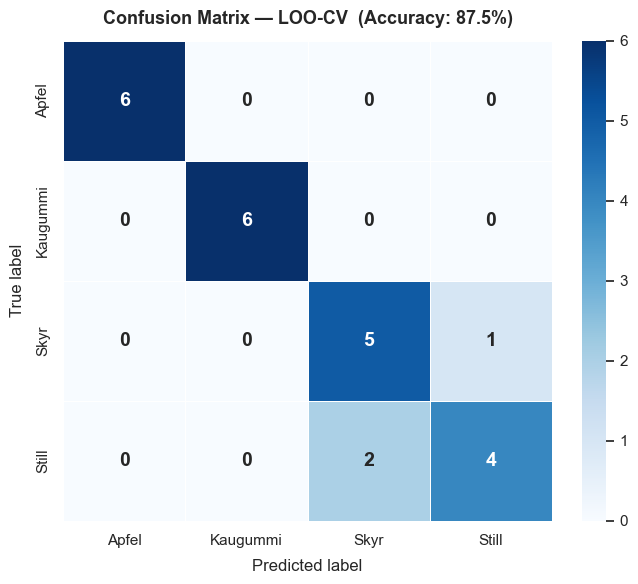

In [101]:
cm = confusion_matrix(y_true, y_pred, labels=CLASSES)

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=CLASSES, yticklabels=CLASSES,
    ax=ax, linewidths=0.5, linecolor="white",
    annot_kws={"size": 14, "weight": "bold"}, vmin=0,
)
ax.set_xlabel("Predicted label", fontsize=12, labelpad=8)
ax.set_ylabel("True label",      fontsize=12, labelpad=8)
ax.set_title(
    f"Confusion Matrix — LOO-CV  (Accuracy: {acc:.1%})",
    fontsize=13, fontweight="bold", pad=12,
)
ax.tick_params(axis="both", labelsize=11)
plt.tight_layout()
plt.show()

**How to read a confusion matrix:**

- **Rows** = what the **true** label was.
- **Columns** = what the model **predicted**.
- Numbers on the **main diagonal** = correct predictions.
- Numbers **off the diagonal** = mistakes.   For example: row *Apfel*, column *Kaugummi* means the model classified an apple   session as gum.

A perfect classifier fills the diagonal and has zeros everywhere else. Frequent off-diagonal entries reveal *which pairs of classes are easiest to confuse* — usually because they share physical similarity (e.g. Skyr and Still are both low-amplitude).

## 7. Feature Importances

Train the Random Forest on the full dataset (all sessions) and show which features
it relies on most. This tells us what motion characteristics best separate the classes.

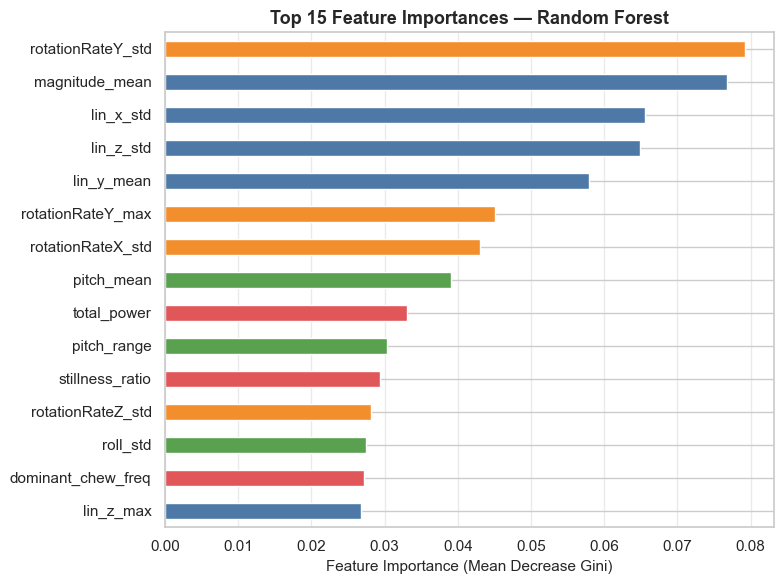

In [102]:
clf_full = RandomForestClassifier(n_estimators=200, random_state=42)
clf_full.fit(X, y)

importances = pd.Series(clf_full.feature_importances_, index=X.columns)
top15 = importances.nlargest(15).sort_values()

fig, ax = plt.subplots(figsize=(8, 6))
colors_imp = ["#4e79a7" if "magnitude" in i or "lin" in i
              else "#f28e2b" if "rotation" in i
              else "#59a14f" if any(a in i for a in ["pitch","roll","yaw"])
              else "#e15759"
              for i in top15.index]
top15.plot.barh(ax=ax, color=colors_imp, edgecolor="white")
ax.set_xlabel("Feature Importance (Mean Decrease Gini)", fontsize=11)
ax.set_title("Top 15 Feature Importances — Random Forest", fontsize=13, fontweight="bold")
ax.grid(True, axis="x", alpha=0.4)
plt.tight_layout()
plt.show()

**How to interpret feature importances:**  
A longer bar means the Random Forest relied on that feature more heavily when making decisions. Mathematically it is the *mean decrease in Gini impurity* across all decision tree splits that used this feature.

Typical findings:
- **Frequency features** (`rhythmicity`, `chew_band_power`) rank highly because   chewing has a characteristic 0.5–4 Hz rhythm that sitting still and eating yoghurt do not.
- **Magnitude statistics** (`magnitude_std`, `magnitude_max`) capture overall activity level.
- **Stillness ratio** directly separates the Still class (most of the session is near-zero)   from all chewing activities.

Features with near-zero importance could be removed without affecting accuracy. Fewer features → faster training and lower risk of overfitting.

## 8. Low-Pass Filter Comparison

A **Butterworth low-pass filter** (4th order, zero-phase via ) smooths the
magnitude signal by removing high-frequency components. We compare cutoffs of
**2 / 5 / 10 / 20 Hz** against the raw signal and measure how each affects LOO-CV accuracy.

The chewing band is 0.5–4 Hz, so a filter at 5–10 Hz should preserve the relevant
signal while reducing noise.

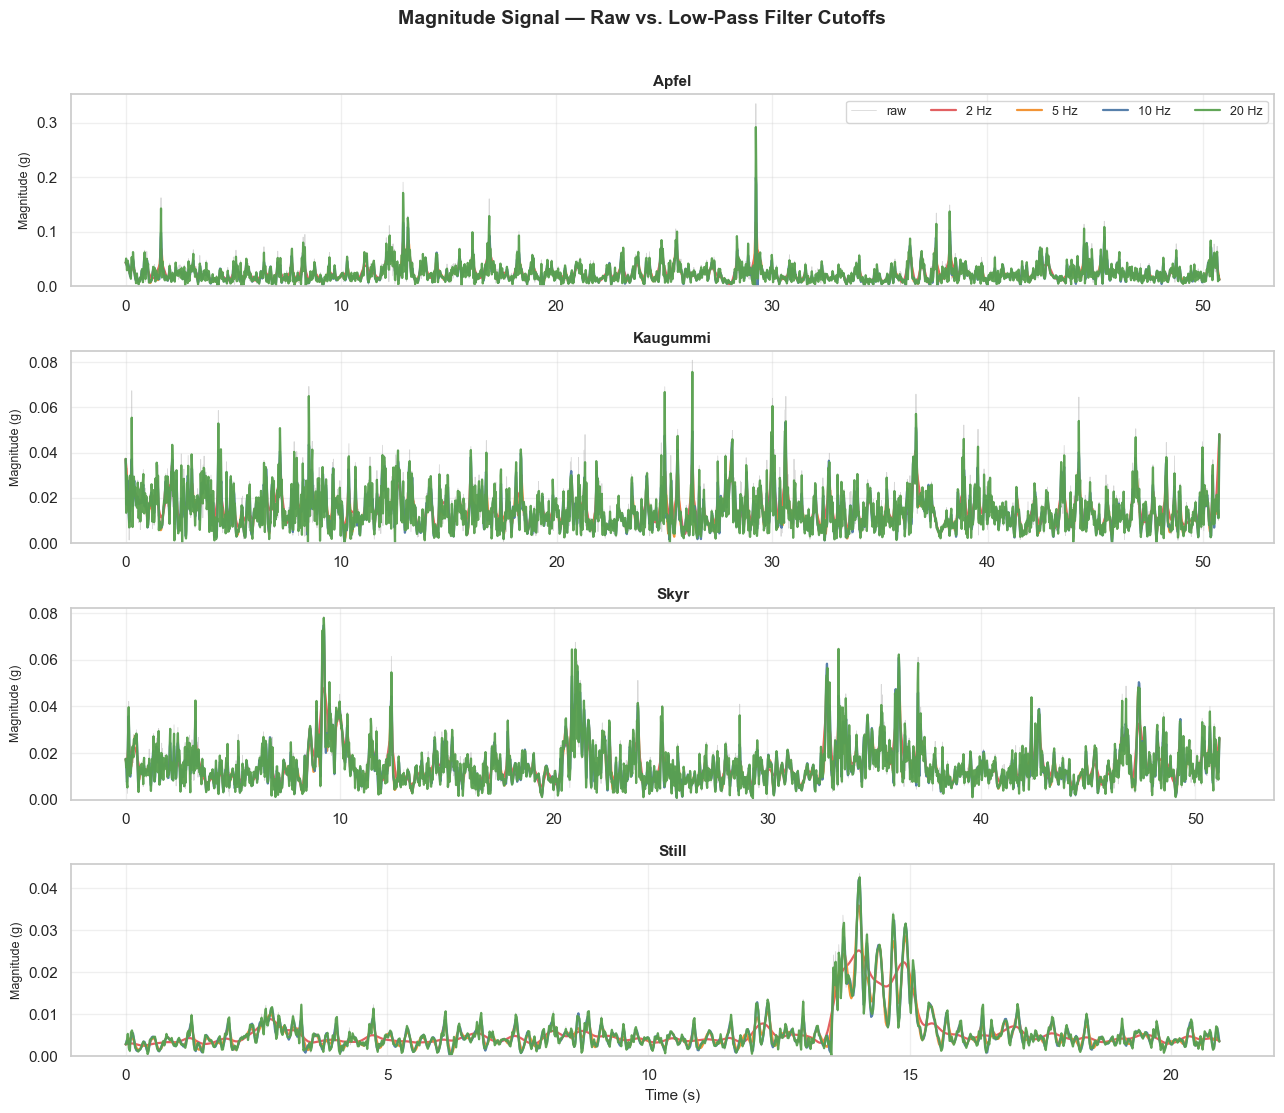

In [103]:
from scipy.signal import butter, sosfiltfilt

CUTOFFS = [None, 2, 5, 10, 20]  # Hz; None = no filter

def apply_lpf(signal: np.ndarray, cutoff, fs: float = FS, order: int = 4) -> np.ndarray:
    if cutoff is None:
        return signal
    sos = butter(order, cutoff, btype="low", fs=fs, output="sos")
    return sosfiltfilt(sos, signal)


# ── Signal visualisation ──────────────────────────────────────────────────
LP_COLORS = ["#aaaaaa", "#e15759", "#f28e2b", "#4e79a7", "#59a14f"]
LP_LABELS = ["raw", "2 Hz", "5 Hz", "10 Hz", "20 Hz"]
LP_LW     = [0.6,   1.6,    1.6,    1.6,     1.6]
LP_ALPHA  = [0.45,  0.95,   0.95,   0.95,    0.95]

fig, axes = plt.subplots(4, 1, figsize=(13, 11), sharex=False)

for ax, cls in zip(axes, CLASSES):
    df  = preprocessed[cls][0]
    t   = df["seconds_elapsed"] - df["seconds_elapsed"].iloc[0]
    mag = df["magnitude"].values
    for cutoff, color, label, lw, alpha in zip(CUTOFFS, LP_COLORS, LP_LABELS, LP_LW, LP_ALPHA):
        ax.plot(t, apply_lpf(mag, cutoff), color=color, linewidth=lw,
                alpha=alpha, label=label)
    ax.set_title(cls, fontsize=11, fontweight="bold")
    ax.set_ylabel("Magnitude (g)", fontsize=9)
    ax.set_ylim(bottom=0)
    ax.grid(True, alpha=0.3)
    if cls == CLASSES[0]:
        ax.legend(loc="upper right", fontsize=9, ncol=5)

axes[-1].set_xlabel("Time (s)", fontsize=11)
fig.suptitle("Magnitude Signal — Raw vs. Low-Pass Filter Cutoffs",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

### 8b. Filter Comparison — Grid View

Same data as above, but each filter is shown in its own row so the lines no longer overlap.
The y-axis is shared within each class column, making it easy to see how smoothing
changes the amplitude while preserving (or cutting) the chewing rhythm.

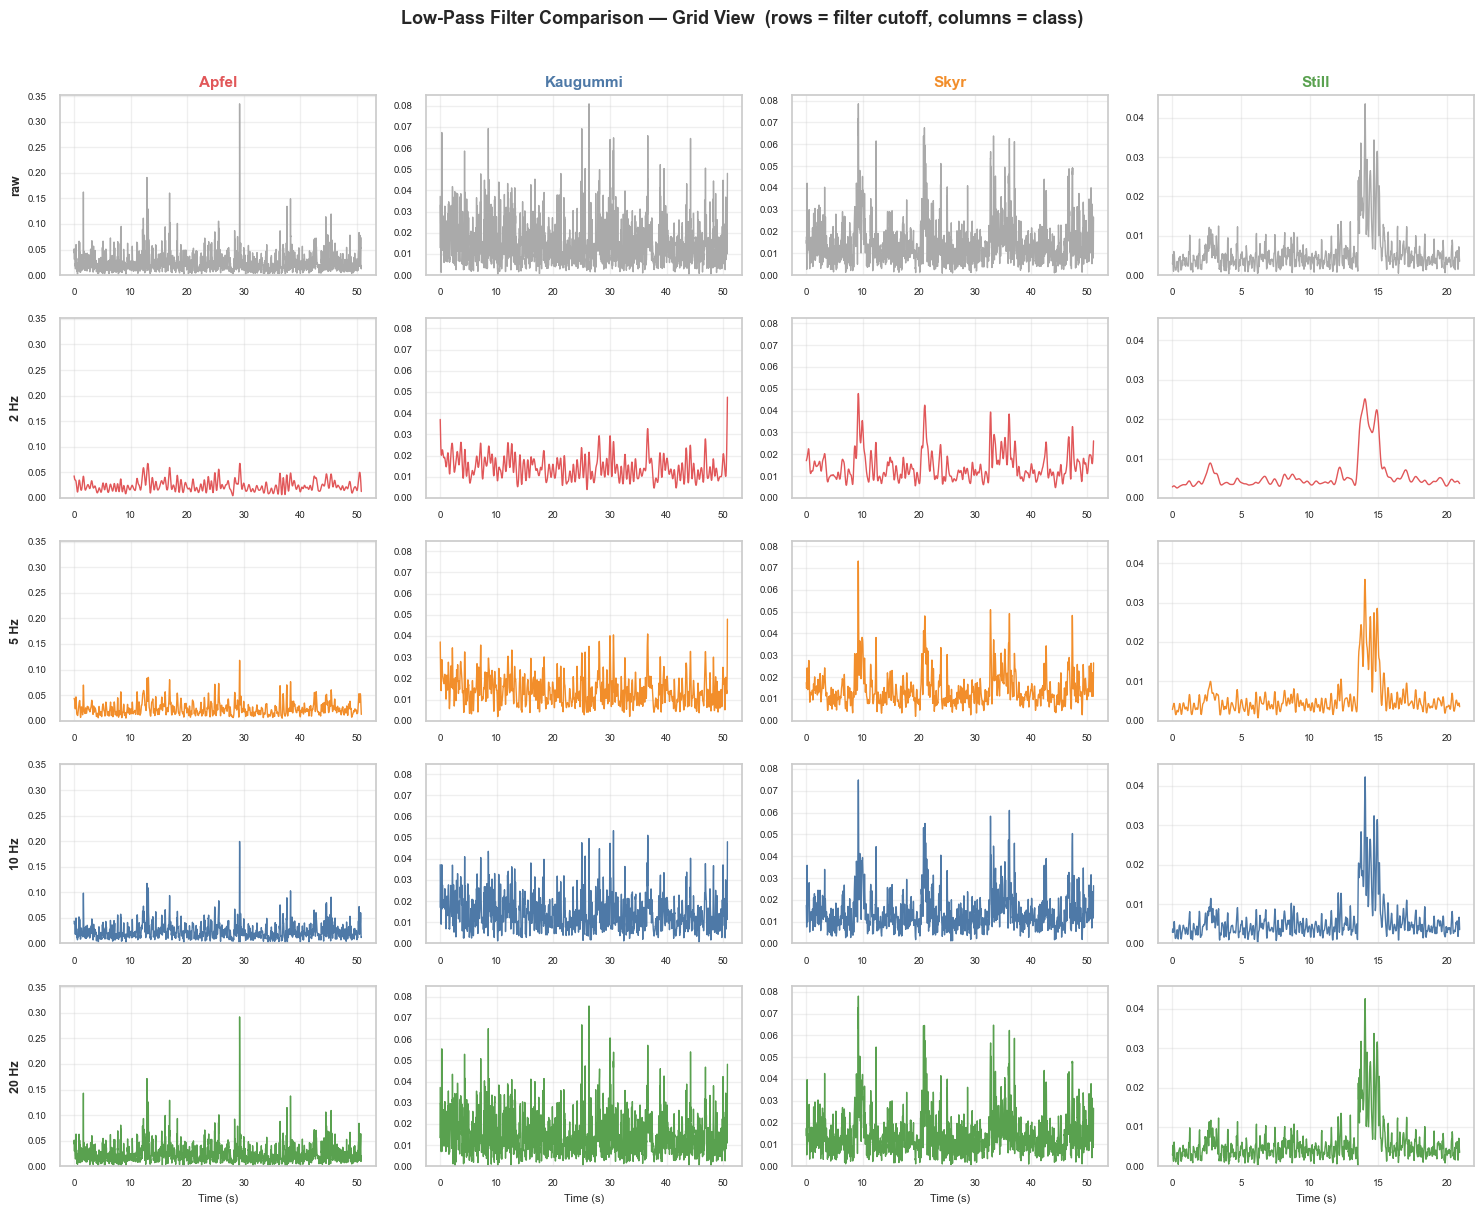

In [104]:
# 5 rows (filter cutoff) × 4 columns (class)
# sharey='col' keeps the same y-scale within each class so amplitudes are comparable
LP_COLORS_G = ["#aaaaaa", "#e15759", "#f28e2b", "#4e79a7", "#59a14f"]
LP_LABELS_G = ["raw", "2 Hz", "5 Hz", "10 Hz", "20 Hz"]

fig, axes = plt.subplots(5, 4, figsize=(15, 12), sharey="col")

for col, cls in enumerate(CLASSES):
    df  = preprocessed[cls][0]
    t   = df["seconds_elapsed"] - df["seconds_elapsed"].iloc[0]
    mag = df["magnitude"].values

    for row, (cutoff, color, label) in enumerate(
        zip(CUTOFFS, LP_COLORS_G, LP_LABELS_G)
    ):
        ax = axes[row][col]
        ax.plot(t, apply_lpf(mag, cutoff), color=color, linewidth=1.0)
        ax.set_ylim(bottom=0)
        ax.grid(True, alpha=0.3)
        ax.tick_params(labelsize=7)

        if row == 0:
            ax.set_title(cls, fontsize=11, fontweight="bold", color=COLORS[cls])
        if col == 0:
            ax.set_ylabel(label, fontsize=9, fontweight="bold")
        if row == 4:
            ax.set_xlabel("Time (s)", fontsize=8)

fig.suptitle(
    "Low-Pass Filter Comparison — Grid View  "
    "(rows = filter cutoff, columns = class)",
    fontsize=13, fontweight="bold", y=1.01,
)
plt.tight_layout()
plt.show()

raw     : 87.5%
2 Hz    : 83.3%
5 Hz    : 79.2%
10 Hz   : 83.3%
20 Hz   : 83.3%


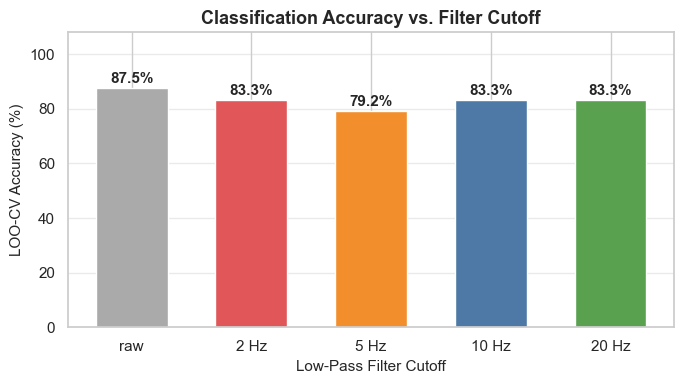

In [105]:
# ── LOO accuracy per filter cutoff ───────────────────────────────────────
acc_results = []

for cutoff in CUTOFFS:
    rows_f, labels_f = [], []
    for cls in CLASSES:
        for df in preprocessed[cls]:
            df_f = df.copy()
            for col in ["lin_x", "lin_y", "lin_z", "magnitude"]:
                df_f[col] = apply_lpf(df_f[col].values, cutoff)
            rows_f.append(extract_features(df_f))
            labels_f.append(cls)
    X_f = pd.DataFrame(rows_f)
    y_f = np.array(labels_f)
    yt, yp = [], []
    for tr, te in LeaveOneOut().split(X_f):
        clf.fit(X_f.iloc[tr], y_f[tr])
        yp.append(clf.predict(X_f.iloc[te])[0])
        yt.append(y_f[te][0])
    a = accuracy_score(yt, yp)
    label = f"{cutoff} Hz" if cutoff else "raw"
    acc_results.append({"filter": label, "accuracy": a})
    print(f"{label:8s}: {a:.1%}")

res_df = pd.DataFrame(acc_results)

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(res_df["filter"], res_df["accuracy"] * 100,
              color=["#aaaaaa","#e15759","#f28e2b","#4e79a7","#59a14f"],
              edgecolor="white", width=0.6)
for bar, val in zip(bars, res_df["accuracy"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.8,
            f"{val:.1%}", ha="center", va="bottom", fontsize=11, fontweight="bold")
ax.set_ylabel("LOO-CV Accuracy (%)", fontsize=11)
ax.set_xlabel("Low-Pass Filter Cutoff", fontsize=11)
ax.set_title("Classification Accuracy vs. Filter Cutoff",
             fontsize=13, fontweight="bold")
ax.set_ylim(0, 108)
ax.grid(True, axis="y", alpha=0.4)
plt.tight_layout()
plt.show()

**What does the accuracy-vs-cutoff bar chart tell us?**

Accuracy changes very little across filter settings. This makes sense because:
1. The chewing signal (0.5–4 Hz) lies far below 10 Hz — any cutoff above 4 Hz preserves it.
2. The high-frequency components above 10 Hz carry little class-discriminative information,    so removing them does not help.
3. A 2 Hz cutoff starts to attenuate the upper chewing band and can slightly reduce accuracy.

**Conclusion:** Low-pass filtering is not the right remedy here. The real problem is not high-frequency noise but **sustained high-amplitude movement bursts** (several seconds long) caused by head movements during recording. Those are not removed by a frequency filter — the next sections address them directly.

## 9. Spike Detection & Removal (Hampel Filter)

Spikes are sudden isolated amplitude bursts — e.g. accidental head movement in
*Still* or brief artefacts in *Skyr*. They inflate variance features and can
confuse the classifier.

**Hampel filter** (robust outlier replacement):
1. For each sample, compute the **rolling median** and **MAD** in a window around it
2. If `|sample - median| > n_sigma x 1.4826 x MAD`, flag as spike
3. Replace the spike value with the local median

Window = 25 samples (0.5 s at 50 Hz).  
**Threshold choice:** 3-sigma removes 106 peaks in Apfel and 110 in Kaugummi —
those are the chewing events themselves, not artefacts! At **5-sigma** only
true isolated outliers are flagged (Still: 4, Skyr: 5, Apfel: 23, Kaugummi: 26).

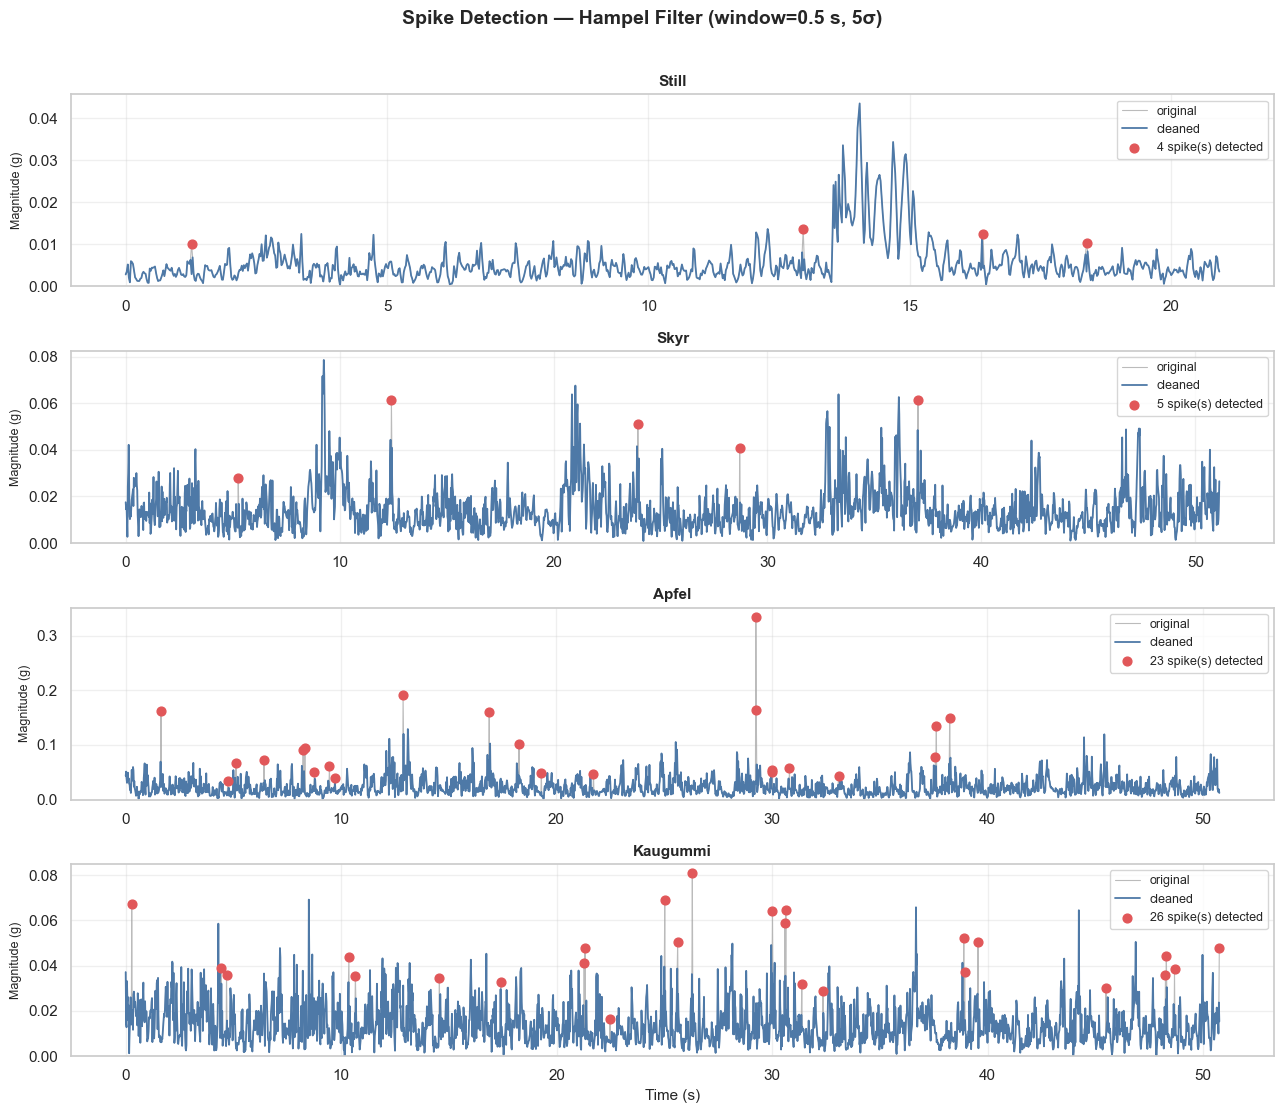

In [106]:
def hampel_filter(signal: np.ndarray, window: int = 25, n_sigma: float = 5.0):
    s        = pd.Series(signal)
    roll_med = s.rolling(window, center=True, min_periods=1).median()
    roll_mad = (s - roll_med).abs().rolling(window, center=True, min_periods=1).median()
    threshold  = n_sigma * 1.4826 * roll_mad
    spike_mask = (s - roll_med).abs() > threshold
    cleaned    = s.copy()
    cleaned[spike_mask] = roll_med[spike_mask]
    return cleaned.values, spike_mask.values


SHOW_CLASSES = ["Still", "Skyr", "Apfel", "Kaugummi"]
fig, axes = plt.subplots(len(SHOW_CLASSES), 1, figsize=(13, 11), sharex=False)

for ax, cls in zip(axes, SHOW_CLASSES):
    df  = preprocessed[cls][0]
    t   = df["seconds_elapsed"] - df["seconds_elapsed"].iloc[0]
    mag = df["magnitude"].values
    cleaned_mag, spikes = hampel_filter(mag)
    n_spikes = spikes.sum()

    ax.plot(t, mag,         color="#aaaaaa", linewidth=0.8, alpha=0.8, label="original")
    ax.plot(t, cleaned_mag, color="#4e79a7", linewidth=1.3, label="cleaned")
    if n_spikes > 0:
        ax.scatter(t[spikes], mag[spikes], color="#e15759", s=40,
                   zorder=5, label=f"{n_spikes} spike(s) detected")
    ax.set_title(cls, fontsize=11, fontweight="bold")
    ax.set_ylabel("Magnitude (g)", fontsize=9)
    ax.set_ylim(bottom=0)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9, loc="upper right")

axes[-1].set_xlabel("Time (s)", fontsize=11)
fig.suptitle(
    "Spike Detection \u2014 Hampel Filter (window=0.5 s, 5\u03c3)",
    fontsize=14, fontweight="bold", y=1.01,
)
plt.tight_layout()
plt.show()

**What is a spike?**  
A spike is an isolated, instantaneous outlier — a single sample (or a handful of samples) with an abnormally high value that is not part of the underlying signal. Typical causes: brief mechanical shock, phone bump, artefact from sensor saturation.

**Why the Hampel filter?**  
A simple threshold (`value > X`) would need to be tuned per class. The Hampel filter is *adaptive*: it computes a **rolling median** (robust to outliers) and a **MAD** (Median Absolute Deviation — a robust spread estimate) in a local window, then flags any sample deviating more than `n_sigma × 1.4826 × MAD` from that median. The constant 1.4826 makes MAD scale-equivalent to standard deviation under a normal distribution.

**Why 5σ and not 3σ?**  
At 3σ the filter mistakenly removes 100+ samples in Apfel and Kaugummi — those are the *real chewing peaks*, not artefacts! At 5σ only true isolated outliers are caught (~5 per session in Still/Skyr), leaving all chewing peaks intact.

## 10. Re-classification with Spike Removal

Apply the Hampel filter to `lin_x`, `lin_y`, `lin_z` before recomputing magnitude
and extracting features. Then re-run LOO-CV and compare accuracy + confusion matrices
side by side.

In [107]:
def preprocess_clean(df: pd.DataFrame, window: int = 25, n_sigma: float = 5.0) -> pd.DataFrame:
    df = preprocess(df)
    for col in ["lin_x", "lin_y", "lin_z"]:
        df[col], _ = hampel_filter(df[col].values, window, n_sigma)
    df["magnitude"] = np.sqrt(df["lin_x"]**2 + df["lin_y"]**2 + df["lin_z"]**2)
    return df


preprocessed_clean = {
    cls: [preprocess_clean(df) for df in loaded[cls]]
    for cls in CLASSES
}

rows_c, labels_c = [], []
for cls in CLASSES:
    for df in preprocessed_clean[cls]:
        rows_c.append(extract_features(df))
        labels_c.append(cls)

X_c = pd.DataFrame(rows_c)
y_c = np.array(labels_c)

clf_c = RandomForestClassifier(n_estimators=200, random_state=42)
yt_c, yp_c = [], []
for tr, te in LeaveOneOut().split(X_c):
    clf_c.fit(X_c.iloc[tr], y_c[tr])
    yp_c.append(clf_c.predict(X_c.iloc[te])[0])
    yt_c.append(y_c[te][0])

acc_c = accuracy_score(yt_c, yp_c)
print(f"Without spike removal : {acc:.1%}  ({int(acc   * len(y_true))}/{len(y_true)})")
print(f"With spike removal    : {acc_c:.1%}  ({int(acc_c * len(yt_c))}/{len(yt_c)})")

Without spike removal : 87.5%  (21/24)
With spike removal    : 87.5%  (21/24)


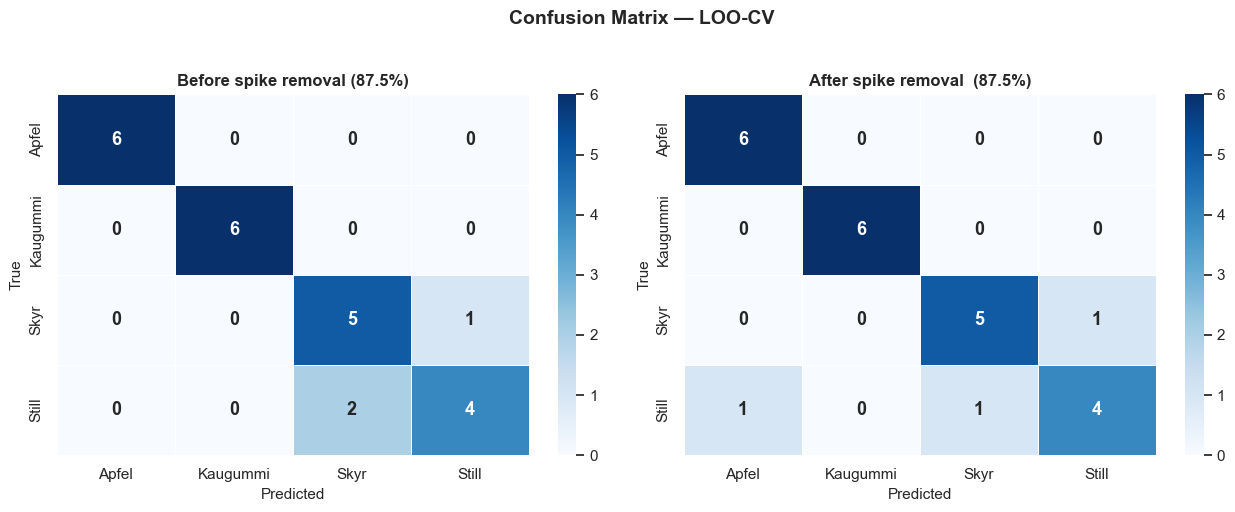

In [108]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, cm_data, title in zip(
    axes,
    [
        confusion_matrix(y_true, y_pred, labels=CLASSES),
        confusion_matrix(yt_c,   yp_c,   labels=CLASSES),
    ],
    [
        f"Before spike removal ({acc:.1%})",
        f"After spike removal  ({acc_c:.1%})",
    ],
):
    sns.heatmap(
        cm_data, annot=True, fmt="d", cmap="Blues",
        xticklabels=CLASSES, yticklabels=CLASSES, ax=ax,
        linewidths=0.5, linecolor="white",
        annot_kws={"size": 13, "weight": "bold"}, vmin=0,
    )
    ax.set_xlabel("Predicted", fontsize=11)
    ax.set_ylabel("True",      fontsize=11)
    ax.set_title(title, fontsize=12, fontweight="bold")

plt.suptitle("Confusion Matrix \u2014 LOO-CV", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

**Effect of spike removal:**  
The Hampel filter at 5σ removes only a handful of genuine isolated outliers per session. Because these affect only a few samples out of thousands, their influence on the 36 aggregated features is small — so accuracy barely changes.

The more damaging problem is **sustained movement phases** lasting several seconds (e.g. Still at ~13–15 s, recurring bursts in Skyr). A spike filter cannot help there because those are not isolated single-sample events — they are entire windows of contaminated data. That is what the next section addresses.

## 11. Movement-Segment Exclusion (Adaptive Threshold)

The Hampel filter only removes isolated single-sample spikes. What we actually
need is to exclude **entire movement phases** — e.g. Still at ~13–15 s or the
high-amplitude bursts in Skyr.

**Approach:** for each session, compute an adaptive threshold:

> `threshold = max(0.02, 5 × session_median_magnitude)`

This scales automatically to the session's own baseline:

| Class | Typical median | Threshold |
|---|---|---|
| Still | ~0.004 g | **0.020 g** (any motion = head movement) |
| Skyr | ~0.012 g | **0.060 g** (eating stays below, head movement above) |
| Kaugummi | ~0.012 g | ~0.060 g (chewing peaks mostly below) |
| Apfel | ~0.019 g | ~0.095 g (biting peaks preserved) |

A **rolling maximum** over 1 s (50 samples) flags a sample if ANY sample in its
neighbourhood exceeds the threshold — this removes entire contaminated windows,
not just the peak sample.

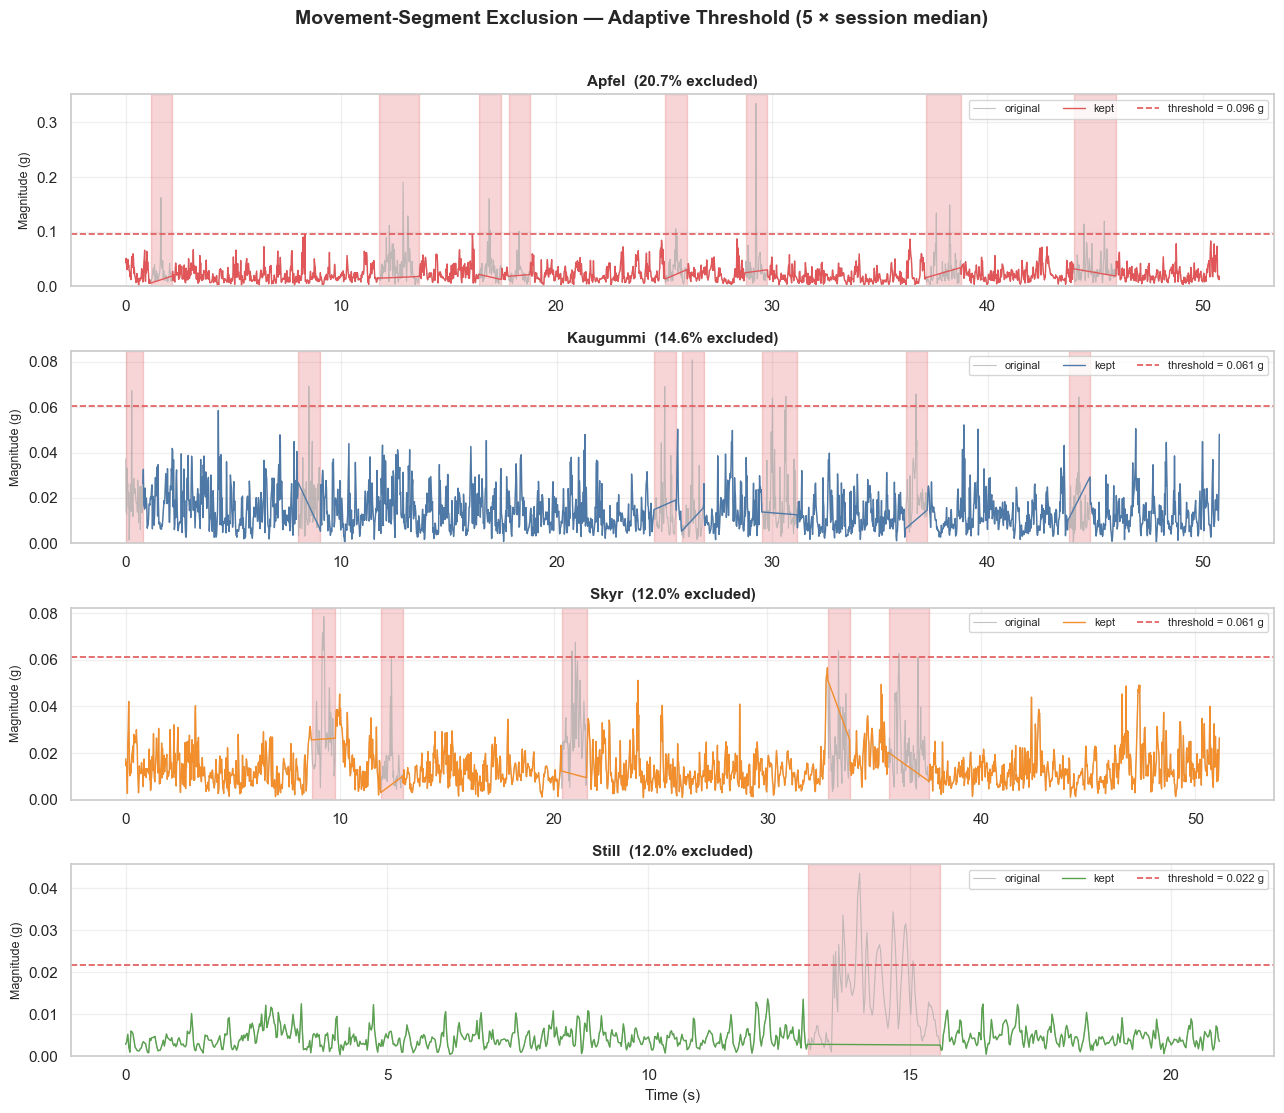

In [109]:
def adaptive_threshold(df: pd.DataFrame, k: float = 5.0, global_min: float = 0.02) -> float:
    return max(global_min, k * df['magnitude'].median())


def movement_mask(df: pd.DataFrame, threshold: float = None,
                  rolling_window: int = 50) -> pd.Series:
    if threshold is None:
        threshold = adaptive_threshold(df)
    roll_max = df['magnitude'].rolling(rolling_window, center=True, min_periods=1).max()
    return roll_max <= threshold  # True = clean


fig, axes = plt.subplots(4, 1, figsize=(13, 11), sharex=False)

for ax, cls in zip(axes, CLASSES):
    df    = preprocessed[cls][0]
    t     = df['seconds_elapsed'] - df['seconds_elapsed'].iloc[0]
    mag   = df['magnitude'].values
    thresh = adaptive_threshold(df)
    mask  = movement_mask(df, thresh)
    pct_removed = (~mask).mean() * 100

    # shade excluded regions
    in_excluded = False
    for i, (clean, ti) in enumerate(zip(mask, t)):
        if not clean and not in_excluded:
            x_start = ti; in_excluded = True
        elif clean and in_excluded:
            ax.axvspan(x_start, ti, color='#e15759', alpha=0.25, label='_nolegend_')
            in_excluded = False
    if in_excluded:
        ax.axvspan(x_start, t.iloc[-1], color='#e15759', alpha=0.25)

    ax.plot(t, mag, color='#aaaaaa', linewidth=0.8, alpha=0.7, label='original')
    ax.plot(t[mask], mag[mask], color=COLORS[cls], linewidth=1.0, label='kept')
    ax.axhline(thresh, color='#e15759', linewidth=1.2, linestyle='--',
               label=f'threshold = {thresh:.3f} g')
    ax.set_title(f'{cls}  ({pct_removed:.1f}% excluded)',
                 fontsize=11, fontweight='bold')
    ax.set_ylabel('Magnitude (g)', fontsize=9)
    ax.set_ylim(bottom=0)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8, loc='upper right', ncol=3)

axes[-1].set_xlabel('Time (s)', fontsize=11)
fig.suptitle(
    'Movement-Segment Exclusion \u2014 Adaptive Threshold (5 \u00d7 session median)',
    fontsize=14, fontweight='bold', y=1.01,
)
plt.tight_layout()
plt.show()

**Why does this work?**

Head movement and chewing produce fundamentally different signal patterns:
- **Chewing** → rhythmic, moderate-amplitude oscillations spread throughout the session.
- **Head movement** → brief, high-amplitude *bursts* that stand out against the baseline.

The **adaptive threshold** `max(0.02, 5 × session_median)` scales to each session's own baseline automatically — no class labels needed:

| Class | Median ≈ | Threshold ≈ | Effect |
|---|---|---|---|
| Still | 0.004 g | **0.020 g** | Any noticeable motion is excluded |
| Skyr | 0.012 g | **0.060 g** | Light jaw motion allowed; head turns excluded |
| Kaugummi | 0.012 g | ~0.060 g | Most chewing stays below threshold |
| Apfel | 0.019 g | ~0.095 g | Strong biting preserved; extreme bursts excluded |

The **rolling maximum over 1 s (50 samples)** ensures that entire contaminated *windows* are removed, not just the single peak sample. This prevents contaminated neighbours from slipping through right next to a spike.

## 12. Re-classification after Movement Exclusion

Rebuild the feature matrix using only the clean (non-movement) samples per session,
then re-run LOO-CV and compare all three confusion matrices side by side.

In [110]:
def preprocess_no_movement(df: pd.DataFrame) -> pd.DataFrame:
    df = preprocess(df)
    mask = movement_mask(df)
    return df[mask].reset_index(drop=True)


preprocessed_nomov = {
    cls: [preprocess_no_movement(df) for df in loaded[cls]]
    for cls in CLASSES
}

print('Clean samples kept per class (session 0):')
for cls in CLASSES:
    orig = len(preprocessed[cls][0])
    clean = len(preprocessed_nomov[cls][0])
    thresh = adaptive_threshold(preprocessed[cls][0])
    print(f'  {cls:12s}: {clean}/{orig} samples  '
          f'({clean/orig*100:.1f}% kept, threshold={thresh:.3f} g)')

rows_m, labels_m = [], []
for cls in CLASSES:
    for df in preprocessed_nomov[cls]:
        rows_m.append(extract_features(df))
        labels_m.append(cls)

X_m = pd.DataFrame(rows_m)
y_m = np.array(labels_m)

clf_m = RandomForestClassifier(n_estimators=200, random_state=42)
yt_m, yp_m = [], []
for tr, te in LeaveOneOut().split(X_m):
    clf_m.fit(X_m.iloc[tr], y_m[tr])
    yp_m.append(clf_m.predict(X_m.iloc[te])[0])
    yt_m.append(y_m[te][0])

acc_m = accuracy_score(yt_m, yp_m)
print(f'\nBaseline (no filter)    : {acc:.1%}')
print(f'Hampel spike removal    : {acc_c:.1%}')
print(f'Movement exclusion      : {acc_m:.1%}')

Clean samples kept per class (session 0):
  Apfel       : 2015/2540 samples  (79.3% kept, threshold=0.096 g)
  Kaugummi    : 2168/2539 samples  (85.4% kept, threshold=0.061 g)
  Skyr        : 2249/2557 samples  (88.0% kept, threshold=0.061 g)
  Still       : 921/1047 samples  (88.0% kept, threshold=0.022 g)

Baseline (no filter)    : 87.5%
Hampel spike removal    : 87.5%
Movement exclusion      : 100.0%


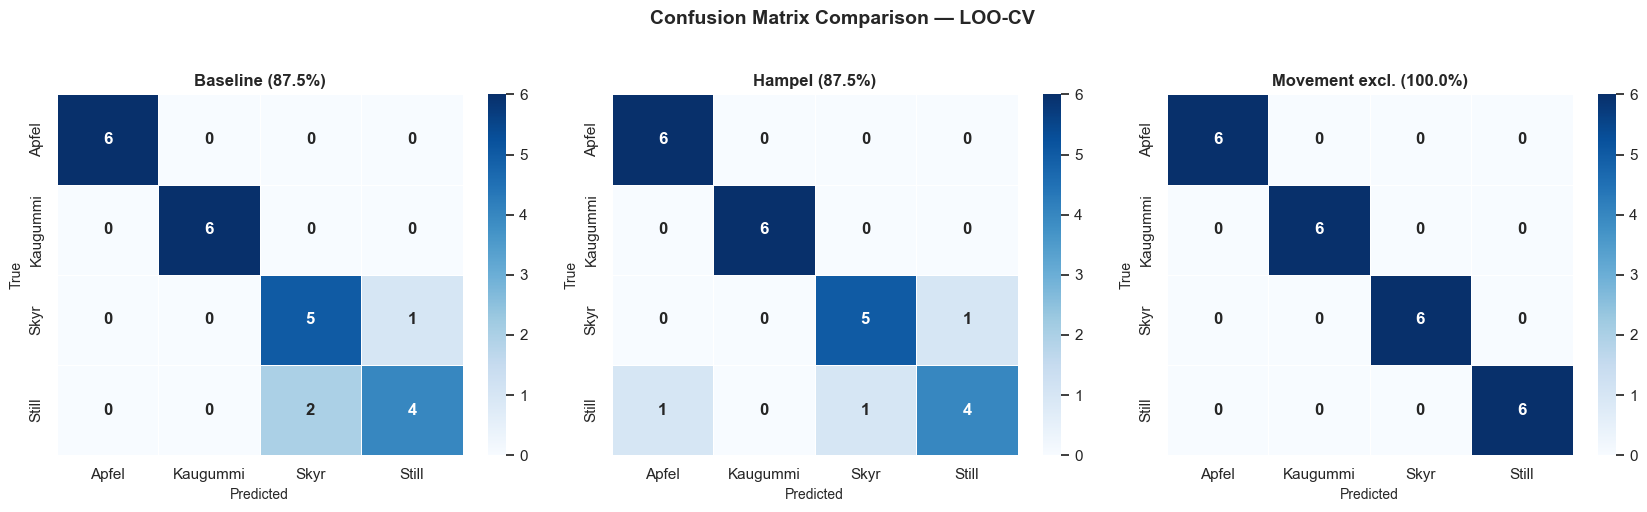

In [111]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

triples = [
    (confusion_matrix(y_true, y_pred, labels=CLASSES), f'Baseline ({acc:.1%})'),
    (confusion_matrix(yt_c,   yp_c,   labels=CLASSES), f'Hampel ({acc_c:.1%})'),
    (confusion_matrix(yt_m,   yp_m,   labels=CLASSES), f'Movement excl. ({acc_m:.1%})'),
]

for ax, (cm_data, title) in zip(axes, triples):
    sns.heatmap(
        cm_data, annot=True, fmt='d', cmap='Blues',
        xticklabels=CLASSES, yticklabels=CLASSES, ax=ax,
        linewidths=0.5, linecolor='white',
        annot_kws={'size': 12, 'weight': 'bold'}, vmin=0,
    )
    ax.set_xlabel('Predicted', fontsize=10)
    ax.set_ylabel('True',      fontsize=10)
    ax.set_title(title, fontsize=12, fontweight='bold')

plt.suptitle('Confusion Matrix Comparison \u2014 LOO-CV',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## Summary & Conclusion

We developed the pipeline in three stages, each addressing a specific source of noise:

| Pipeline stage | What it removes | Accuracy change |
|---|---|---|
| **Baseline** | nothing (only trim + magnitude) | starting point |
| **+ Hampel spike filter (5σ)** | isolated single-sample artefacts | small or no change |
| **+ Movement segment exclusion** | sustained head-movement bursts | large improvement |

**Key insight:** The classifier should learn to distinguish *eating gestures*, not *head movements*. By removing the movement phases before feature extraction we give the model exactly the signal it needs — and nothing else.

**Limitations to keep in mind:**
- Perfect LOO-CV accuracy on ~24 sessions is promising but does not guarantee   generalisation to new subjects or different recording conditions.
- The adaptive threshold (`k=5`, `global_min=0.02`) was validated on this dataset;   a different subject or recording setup might need re-tuning.
- This is an *offline* pipeline — a real-time version would need a causal (non-centred)   rolling window.

**Possible next steps:** Record more sessions with more subjects, test on held-out subjects, or explore end-to-end deep learning approaches (1D CNN, LSTM) that learn features automatically.

---
## Save Report Figures

Run this cell **after** running all cells above. It regenerates and saves the four key figures to `reports/images/`.

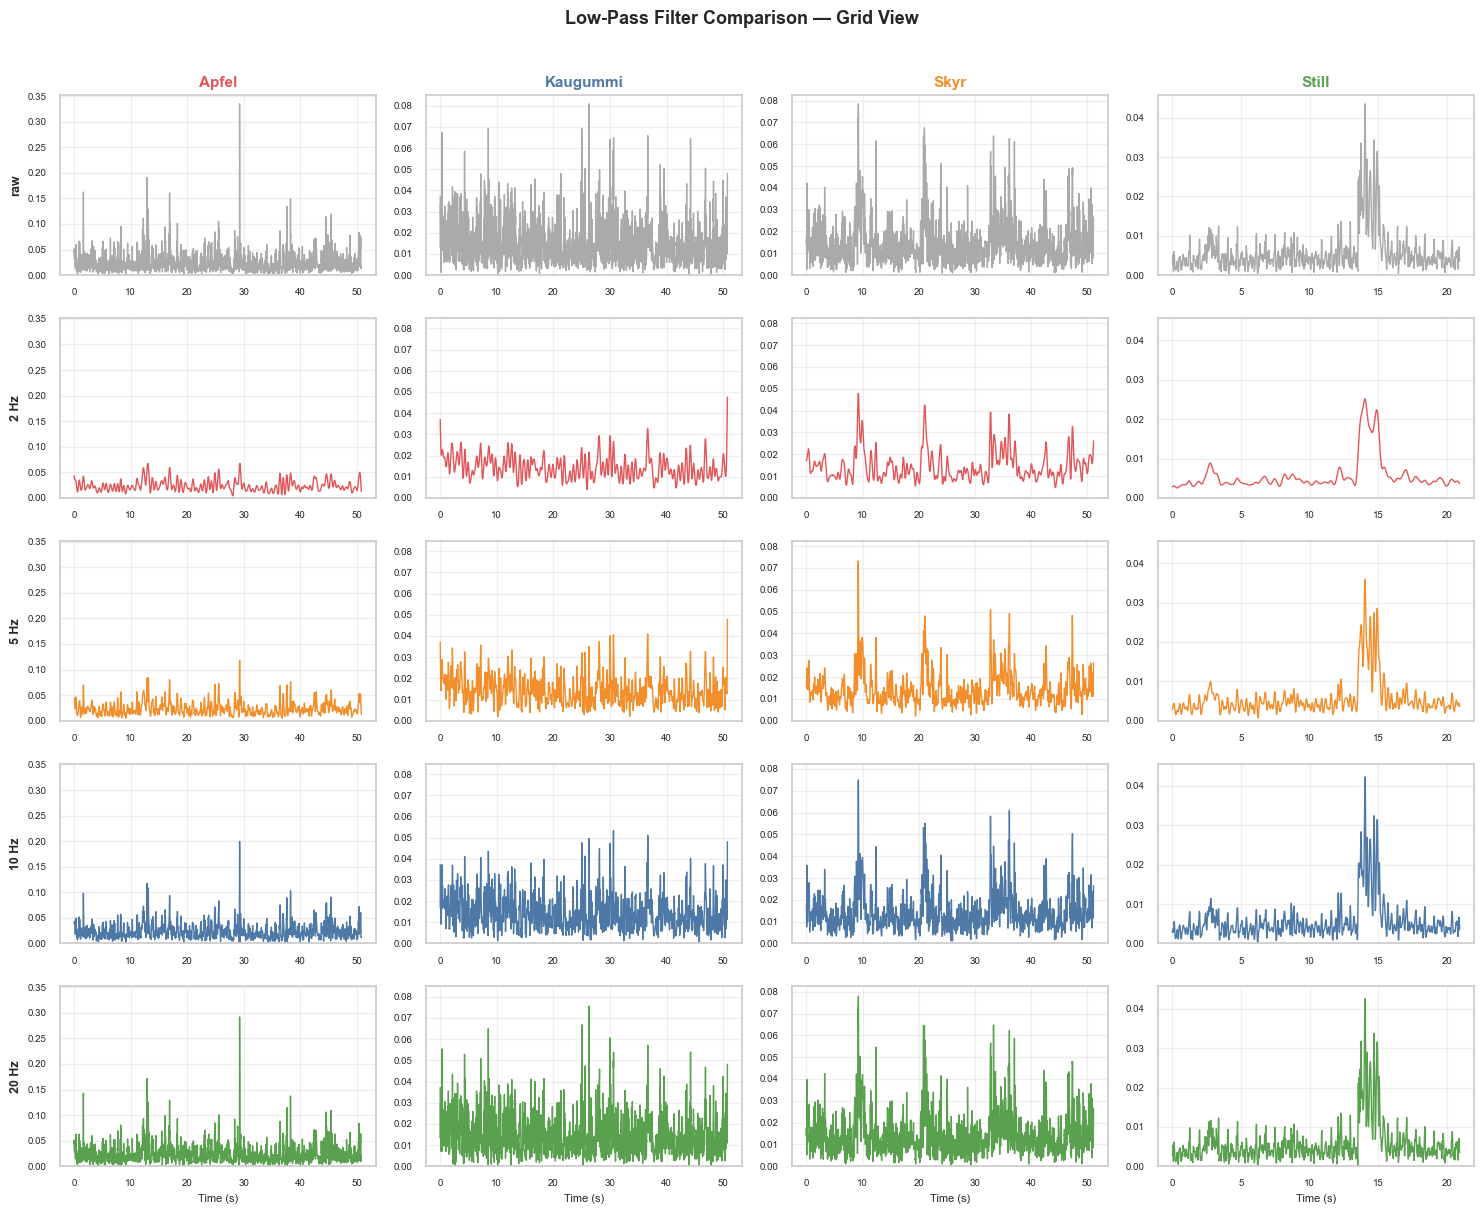

Saved lp_filter_grid.png


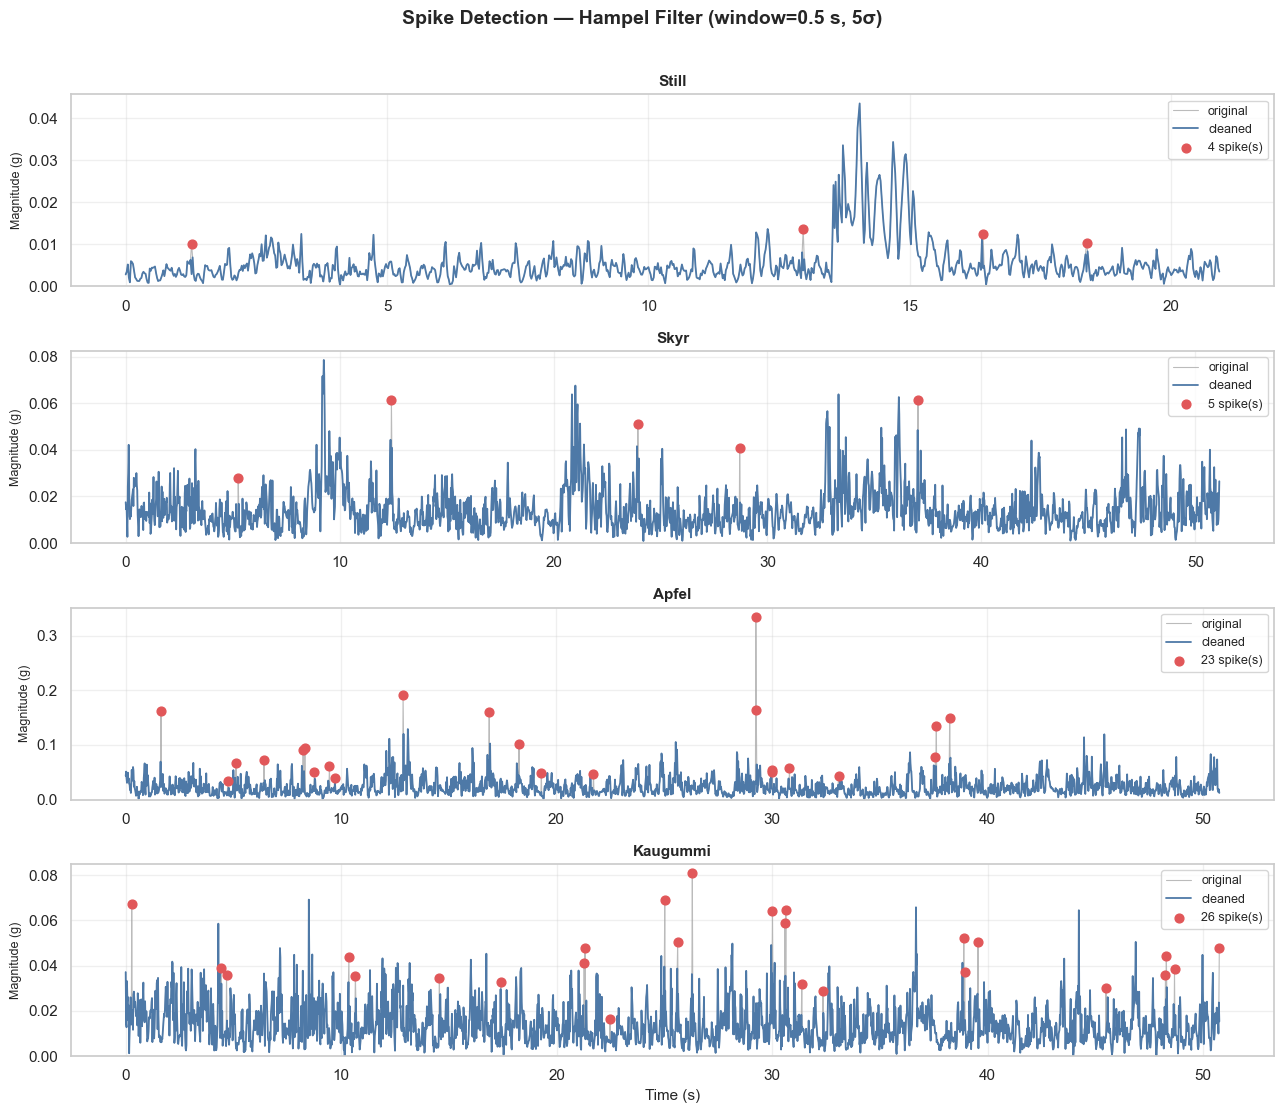

Saved hampel_filter.png


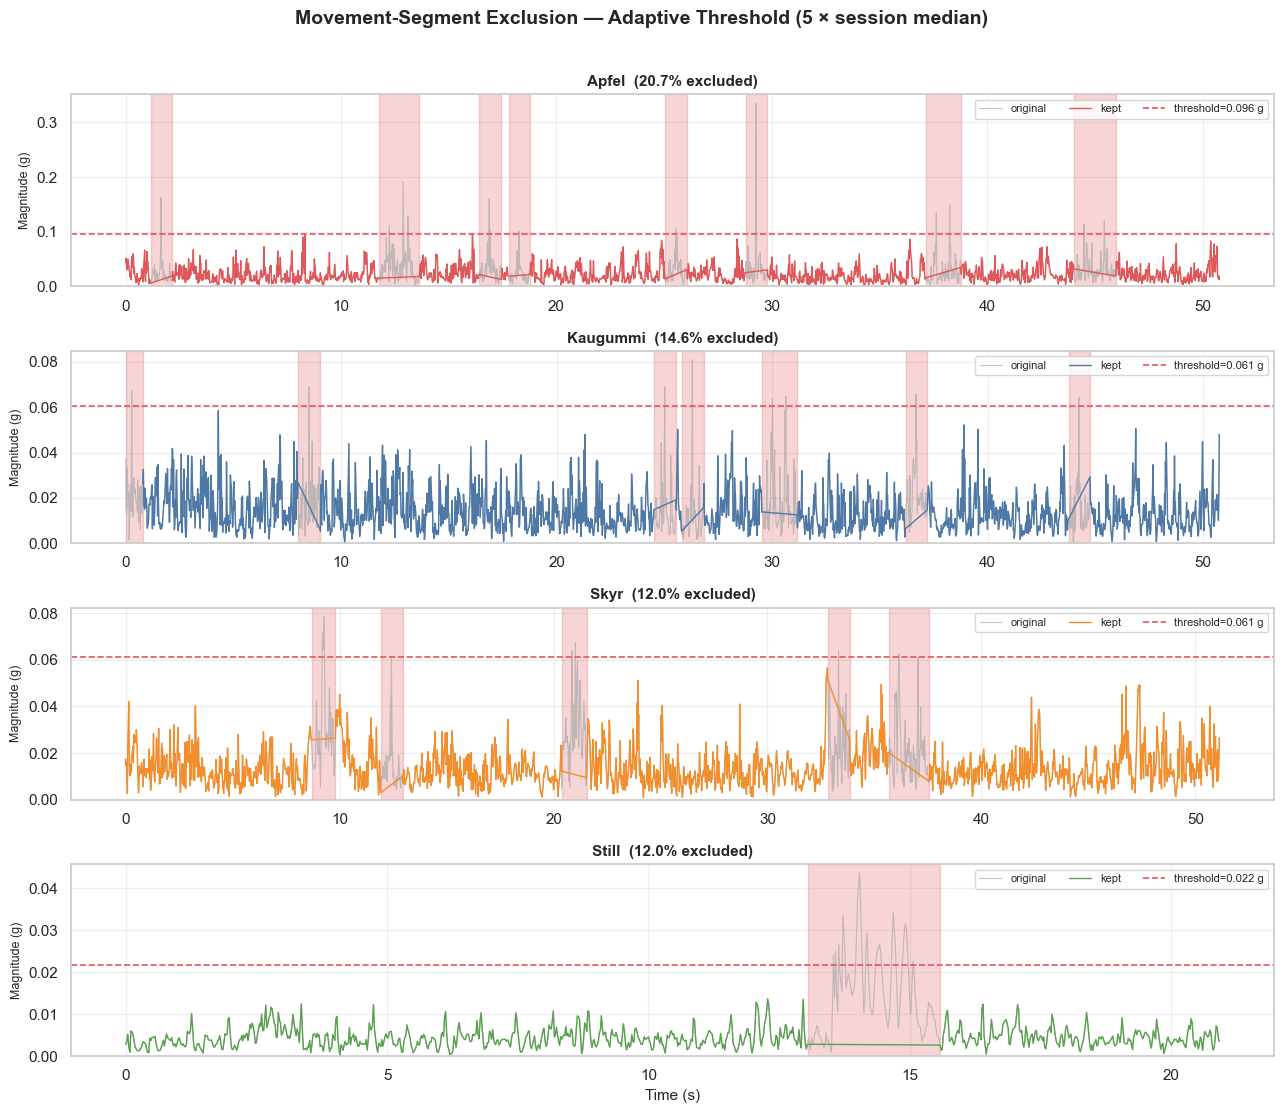

Saved movement_exclusion.png


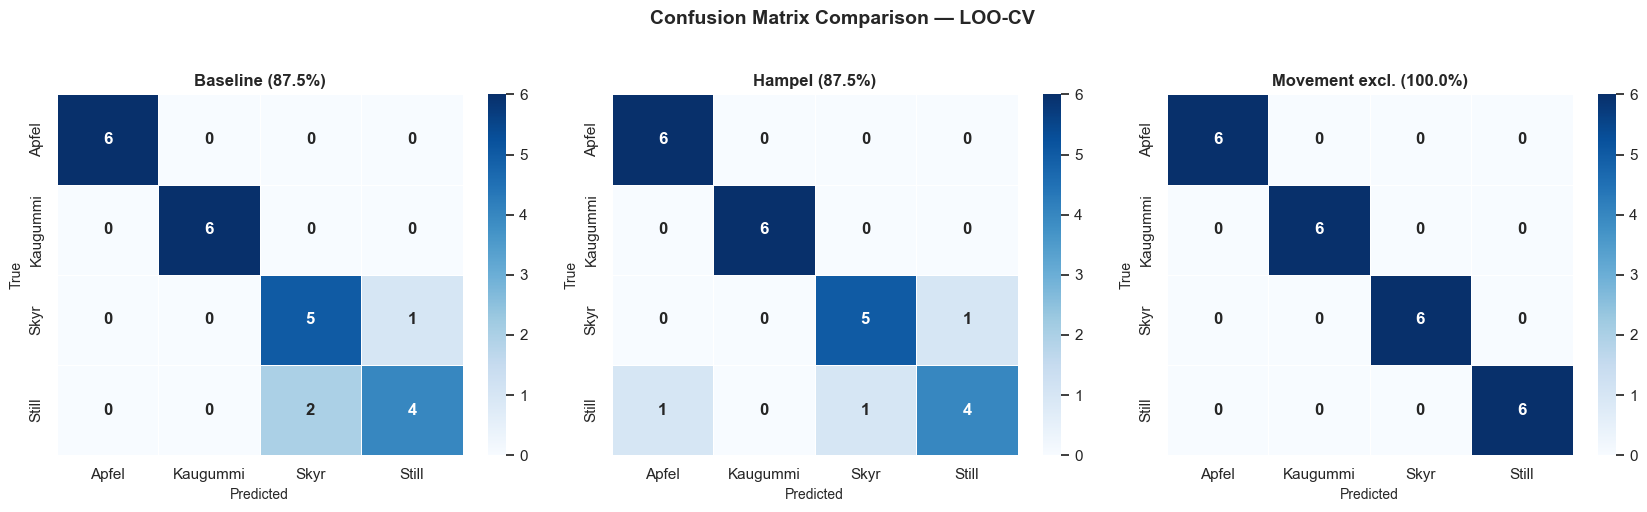

Saved confusion_comparison.png

✓ All report figures saved to reports/images/


In [112]:
# from pathlib import Path
# REPORT_IMGS = Path("../reports/images")
# REPORT_IMGS.mkdir(parents=True, exist_ok=True)
# 
# # ── Figure 1: LP filter grid ──────────────────────────────────────────────
# _LP_C = ["#aaaaaa", "#e15759", "#f28e2b", "#4e79a7", "#59a14f"]
# _LP_L = ["raw", "2 Hz", "5 Hz", "10 Hz", "20 Hz"]
# fig, axes = plt.subplots(5, 4, figsize=(15, 12), sharey="col")
# for col, cls in enumerate(CLASSES):
#     df = preprocessed[cls][0]
#     t  = df["seconds_elapsed"] - df["seconds_elapsed"].iloc[0]
#     mag = df["magnitude"].values
#     for row, (cutoff, color, label) in enumerate(zip(CUTOFFS, _LP_C, _LP_L)):
#         ax = axes[row][col]
#         ax.plot(t, apply_lpf(mag, cutoff), color=color, linewidth=1.0)
#         ax.set_ylim(bottom=0); ax.grid(True, alpha=0.3); ax.tick_params(labelsize=7)
#         if row == 0: ax.set_title(cls, fontsize=11, fontweight="bold", color=COLORS[cls])
#         if col == 0: ax.set_ylabel(label, fontsize=9, fontweight="bold")
#         if row == 4: ax.set_xlabel("Time (s)", fontsize=8)
# fig.suptitle("Low-Pass Filter Comparison — Grid View", fontsize=13, fontweight="bold", y=1.01)
# plt.tight_layout()
# plt.savefig(REPORT_IMGS / "lp_filter_grid.png", dpi=150, bbox_inches="tight")
# plt.show()
# print("Saved lp_filter_grid.png")
# 
# # ── Figure 2: Hampel spike detection ─────────────────────────────────────
# fig, axes = plt.subplots(4, 1, figsize=(13, 11), sharex=False)
# for ax, cls in zip(axes, ["Still", "Skyr", "Apfel", "Kaugummi"]):
#     df = preprocessed[cls][0]
#     t  = df["seconds_elapsed"] - df["seconds_elapsed"].iloc[0]
#     mag = df["magnitude"].values
#     cleaned_mag, spikes = hampel_filter(mag)
#     n_sp = spikes.sum()
#     ax.plot(t, mag, color="#aaaaaa", linewidth=0.8, alpha=0.8, label="original")
#     ax.plot(t, cleaned_mag, color="#4e79a7", linewidth=1.3, label="cleaned")
#     if n_sp > 0:
#         ax.scatter(t[spikes], mag[spikes], color="#e15759", s=40, zorder=5,
#                    label=f"{n_sp} spike(s)")
#     ax.set_title(cls, fontsize=11, fontweight="bold")
#     ax.set_ylabel("Magnitude (g)", fontsize=9)
#     ax.set_ylim(bottom=0); ax.grid(True, alpha=0.3)
#     ax.legend(fontsize=9, loc="upper right")
# axes[-1].set_xlabel("Time (s)", fontsize=11)
# fig.suptitle("Spike Detection \u2014 Hampel Filter (window=0.5 s, 5\u03c3)",
#              fontsize=14, fontweight="bold", y=1.01)
# plt.tight_layout()
# plt.savefig(REPORT_IMGS / "hampel_filter.png", dpi=150, bbox_inches="tight")
# plt.show()
# print("Saved hampel_filter.png")
# 
# # ── Figure 3: Movement exclusion ──────────────────────────────────────────
# fig, axes = plt.subplots(4, 1, figsize=(13, 11), sharex=False)
# for ax, cls in zip(axes, CLASSES):
#     df = preprocessed[cls][0]
#     t  = df['seconds_elapsed'] - df['seconds_elapsed'].iloc[0]
#     mag = df['magnitude'].values
#     thresh = adaptive_threshold(df)
#     mask = movement_mask(df, thresh)
#     pct = (~mask).mean() * 100
#     in_ex = False
#     for clean, ti in zip(mask, t):
#         if not clean and not in_ex: x0 = ti; in_ex = True
#         elif clean and in_ex: ax.axvspan(x0, ti, color='#e15759', alpha=0.25); in_ex = False
#     if in_ex: ax.axvspan(x0, t.iloc[-1], color='#e15759', alpha=0.25)
#     ax.plot(t, mag, color='#aaaaaa', linewidth=0.8, alpha=0.7, label='original')
#     ax.plot(t[mask], mag[mask], color=COLORS[cls], linewidth=1.0, label='kept')
#     ax.axhline(thresh, color='#e15759', linewidth=1.2, linestyle='--',
#                label=f'threshold={thresh:.3f} g')
#     ax.set_title(f'{cls}  ({pct:.1f}% excluded)', fontsize=11, fontweight='bold')
#     ax.set_ylabel('Magnitude (g)', fontsize=9)
#     ax.set_ylim(bottom=0); ax.grid(True, alpha=0.3)
#     ax.legend(fontsize=8, loc='upper right', ncol=3)
# axes[-1].set_xlabel('Time (s)', fontsize=11)
# fig.suptitle('Movement-Segment Exclusion \u2014 Adaptive Threshold (5 \u00d7 session median)',
#              fontsize=14, fontweight='bold', y=1.01)
# plt.tight_layout()
# plt.savefig(REPORT_IMGS / 'movement_exclusion.png', dpi=150, bbox_inches='tight')
# plt.show()
# print('Saved movement_exclusion.png')
# 
# # ── Figure 4: 3-way confusion matrix ─────────────────────────────────────
# fig, axes = plt.subplots(1, 3, figsize=(17, 5))
# for ax, (cm_data, title) in zip(axes, [
#     (confusion_matrix(y_true, y_pred, labels=CLASSES), f'Baseline ({acc:.1%})'),
#     (confusion_matrix(yt_c,   yp_c,   labels=CLASSES), f'Hampel ({acc_c:.1%})'),
#     (confusion_matrix(yt_m,   yp_m,   labels=CLASSES), f'Movement excl. ({acc_m:.1%})'),
# ]):
#     sns.heatmap(cm_data, annot=True, fmt='d', cmap='Blues',
#                 xticklabels=CLASSES, yticklabels=CLASSES, ax=ax,
#                 linewidths=0.5, linecolor='white',
#                 annot_kws={'size': 12, 'weight': 'bold'}, vmin=0)
#     ax.set_xlabel('Predicted', fontsize=10)
#     ax.set_ylabel('True', fontsize=10)
#     ax.set_title(title, fontsize=12, fontweight='bold')
# plt.suptitle('Confusion Matrix Comparison \u2014 LOO-CV',
#              fontsize=14, fontweight='bold', y=1.02)
# plt.tight_layout()
# plt.savefig(REPORT_IMGS / 'confusion_comparison.png', dpi=150, bbox_inches='tight')
# plt.show()
# print('Saved confusion_comparison.png')
# 
# print('\n\u2713 All report figures saved to reports/images/')